# Laboratorio 8 — Máquinas Vectoriales de Soporte (SVM)
**SmartStay Advisors — Airbnb listings**

Universidad del Valle de Guatemala · CC3074 Minería de Datos · Semestre I 2026

## Inciso 1 — Conjuntos de entrenamiento y prueba

Se reutilizan los mismos conjuntos de entrenamiento y prueba de los laboratorios anteriores.
La diferencia respecto al laboratorio 7 es que la variable respuesta es ahora la categórica
de **tres clases** (`economica`, `media`, `cara`) en lugar de la binaria `es_cara`, ya que
las actividades del lab 8 exigen clasificación multiclase con SVM.

El pipeline de limpieza y preparación es idéntico al validado en el laboratorio 6:
- Mismos cortes por tercios (`q1 = 33 %`, `q2 = 66 %`) sobre `price_num`.
- Mismas columnas descartadas (identificadores, URLs, texto libre).
- Misma imputación (mediana para numéricas, `"desconocido"` para categóricas).
- `random_state = 42` y división `70 / 30` con estratificación sobre `price_category`.

In [15]:
import pyreadr
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_selector as selector

SEED = 42
np.random.seed(SEED)

In [16]:
result = pyreadr.read_r("listings.RData")
df = result["listings"].copy()

print(f"Filas y columnas del dataset original: {df.shape}")

Filas y columnas del dataset original: (171748, 80)


In [17]:
filas_antes = len(df)

df["price_num"] = (
    df["price"].astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["price_num"] = df["price_num"].replace({"nan": np.nan, "None": np.nan, "": np.nan})
df["price_num"] = pd.to_numeric(df["price_num"], errors="coerce")
df = df.dropna(subset=["price_num"]).copy()

print(f"Filas antes de limpiar precio: {filas_antes:,}")
print(f"Filas con precio válido:       {len(df):,}")

Filas antes de limpiar precio: 171,748
Filas con precio válido:       76,246


In [18]:
q1, q2 = df["price_num"].quantile([1/3, 2/3])
print(f"q1 (percentil 33) = {q1:.2f}")
print(f"q2 (percentil 66) = {q2:.2f}")

df["price_category"] = pd.cut(
    df["price_num"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["economica", "media", "cara"],
    include_lowest=True,
)

print("\nDistribución de price_category:")
print(df["price_category"].value_counts())

q1 (percentil 33) = 143.00
q2 (percentil 66) = 268.00

Distribución de price_category:
price_category
economica    25689
cara         25404
media        25153
Name: count, dtype: int64


In [19]:
df_model = df.copy()

cols_drop = [
    "id", "listing_url", "scrape_id", "last_scraped", "source",
    "name", "description", "neighborhood_overview", "picture_url",
    "host_url", "host_name", "host_since", "host_location", "host_about",
    "host_thumbnail_url", "host_picture_url", "host_verifications",
    "neighbourhood", "calendar_updated", "calendar_last_scraped",
    "first_review", "last_review", "license", "bathrooms_text", "amenities",
]
cols_drop = [c for c in cols_drop if c in df_model.columns]
df_model = df_model.drop(columns=cols_drop).copy()

high_null = df_model.isnull().mean()
df_model = df_model.drop(columns=high_null[high_null > 0.50].index.tolist()).copy()

bool_cols = ["host_is_superhost", "host_has_profile_pic",
             "host_identity_verified", "has_availability", "instant_bookable"]
for col in bool_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map({"t": 1, "f": 0}).astype("float")

for col in ["host_response_rate", "host_acceptance_rate"]:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype(str).str.replace("%", "", regex=False).str.strip()
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce") / 100

force_numeric = ["bedrooms", "beds", "bathrooms",
                 "minimum_minimum_nights", "maximum_minimum_nights",
                 "minimum_maximum_nights", "maximum_maximum_nights",
                 "host_listings_count", "host_total_listings_count"]
for col in force_numeric:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

numeric_cols_all     = df_model.select_dtypes(include="number").columns.tolist()
categorical_cols_all = df_model.select_dtypes(include="object").columns.tolist()

df_model[numeric_cols_all] = df_model[numeric_cols_all].apply(pd.to_numeric, errors="coerce")
df_model[numeric_cols_all] = df_model[numeric_cols_all].fillna(df_model[numeric_cols_all].median())

for col in categorical_cols_all:
    df_model[col] = df_model[col].where(df_model[col].notna(), "desconocido")
    df_model[col] = df_model[col].astype(str).replace("N/A", "desconocido")

print(f"Filas disponibles para modelar: {len(df_model):,}")
print(f"Columnas totales en df_model:   {df_model.shape[1]}")

Filas disponibles para modelar: 76,246
Columnas totales en df_model:   57


C:\Users\ferna\AppData\Local\Temp\ipykernel_12920\2652310738.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_all = df_model.select_dtypes(include="object").columns.tolist()


In [20]:
excluded_features = [c for c in ["host_id", "estimated_occupancy_l365d", "estimated_revenue_l365d"]
                     if c in df_model.columns]

leak_cols = ["price", "price_num", "price_category", "es_cara", "es_media", "es_economica"]
X_model = df_model.drop(columns=leak_cols + excluded_features, errors="ignore")
y_multi  = df_model["price_category"].copy()

numerical_columns   = selector(dtype_exclude=object)(X_model)
categorical_columns = selector(dtype_include=object)(X_model)

print(f"Variables predictoras: {X_model.shape[1]}")
print(f"  Numéricas:   {len(numerical_columns)}")
print(f"  Categóricas: {len(categorical_columns)}")
print(f"\nDistribución de clases (total):")
print(y_multi.value_counts(normalize=True).round(4))

Variables predictoras: 51
  Numéricas:   44
  Categóricas: 7

Distribución de clases (total):
price_category
economica    0.3369
cara         0.3332
media        0.3299
Name: proportion, dtype: float64


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_multi,
    test_size=0.30,
    train_size=0.70,
    random_state=42,
    stratify=y_multi,
)

print("=== Partición 70/30 estratificada (3 clases) ===")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

proporciones = pd.DataFrame({
    "economica": [y_train.eq("economica").mean(), y_test.eq("economica").mean(), y_multi.eq("economica").mean()],
    "media":     [y_train.eq("media").mean(),     y_test.eq("media").mean(),     y_multi.eq("media").mean()],
    "cara":      [y_train.eq("cara").mean(),      y_test.eq("cara").mean(),      y_multi.eq("cara").mean()],
    "n":         [len(y_train), len(y_test), len(y_multi)],
}, index=["train", "test", "total"]).round(4)
print()
print(proporciones)

=== Partición 70/30 estratificada (3 clases) ===
X_train: (53372, 51)
X_test:  (22874, 51)

       economica   media    cara      n
train     0.3369  0.3299  0.3332  53372
test      0.3369  0.3299  0.3332  22874
total     0.3369  0.3299  0.3332  76246


### Observaciones y conclusiones del inciso 1

- Del dataset original (171,748 filas) se conservaron 76,246 después de descartar las filas sin precio válido. Ese es el universo de trabajo para todo el laboratorio.
- Los cortes por tercios reproducen exactamente los de los laboratorios anteriores: `q1 ≈ $143` y `q2 ≈ $268`. Las tres categorías quedan casi balanceadas (≈ 33 % cada una), lo que facilita interpretar las métricas de clasificación sin necesidad de ajustar pesos de clase.
- La variable respuesta para este laboratorio es `price_category` (tres niveles: `economica`, `media`, `cara`), en lugar de la binaria `es_cara` del laboratorio 7. Eso convierte el problema en clasificación multiclase, que es el escenario natural para SVM con `decision_function_shape="ovr"` o `"ovo"`.
- El split es `70 / 30` con `random_state = 42` y `stratify = y_multi`, lo que garantiza que la proporción de cada clase sea idéntica en entrenamiento y prueba (≈ 0.333 para las tres). Esto asegura comparabilidad con los laboratorios anteriores que usaron la misma semilla y la misma proporción.
- Las variables con fuga eliminadas son las mismas que en el laboratorio 7: `price`, `price_num`, `price_category`, `es_cara`, `es_media`, `es_economica`, `host_id`, `estimated_occupancy_l365d` y `estimated_revenue_l365d`. Sin esa exclusión, el modelo obtendría accuracy perfecta de forma fraudulenta.
- Quedaron aproximadamente 51 variables predictoras (44 numéricas y 7 categóricas), la misma dimensionalidad que en los laboratorios anteriores, garantizando comparabilidad directa de métricas.

## Inciso 2 — Exploración de datos y transformaciones para SVM

Antes de construir cualquier modelo SVM es necesario entender la estructura de los datos
y determinar qué transformaciones son imprescindibles. SVM es especialmente sensible a
la escala de las variables y al costo computacional del entrenamiento, por lo que esta
exploración tiene un propósito doble: detectar problemas y justificar cada decisión de
preprocesamiento que se aplicará en los incisos siguientes.

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Resumen de tipos y cardinalidades de las variables predictoras ===")

type_summary = pd.DataFrame({
    "dtype":    X_model.dtypes,
    "nunique":  X_model.nunique(),
    "pct_null": X_model.isnull().mean().round(4),
})

print("\n--- Numéricas ---")
print(type_summary[type_summary["dtype"] != "object"].sort_values("nunique", ascending=False).to_string())
print("\n--- Categóricas ---")
print(type_summary[type_summary["dtype"] == "object"].sort_values("nunique", ascending=False).to_string())

=== Resumen de tipos y cardinalidades de las variables predictoras ===

--- Numéricas ---
                                                dtype  nunique  pct_null
latitude                                      float64    58213       0.0
longitude                                     float64    56905       0.0
maximum_nights_avg_ntm                        float64     4885       0.0
host_neighbourhood                                str     1750       0.0
reviews_per_month                             float64     1050       0.0
number_of_reviews                               int32      791       0.0
minimum_nights_avg_ntm                        float64      562       0.0
host_total_listings_count                     float64      384       0.0
availability_365                                int32      366       0.0
neighbourhood_cleansed                            str      350       0.0
host_listings_count                           float64      318       0.0
maximum_maximum_nights            

In [23]:
key_num_cols = ["accommodates", "bedrooms", "beds",
                "minimum_nights", "number_of_reviews",
                "review_scores_rating", "host_listings_count"]
key_num_cols = [c for c in key_num_cols if c in X_train.columns]

print("=== Estadísticas descriptivas de variables numéricas clave ===")
print(X_train[key_num_cols].describe().round(2).to_string())

=== Estadísticas descriptivas de variables numéricas clave ===
       accommodates  bedrooms      beds  minimum_nights  number_of_reviews  review_scores_rating  host_listings_count
count      53372.00  53372.00  53372.00        53372.00           53372.00              53372.00             53372.00
mean           4.84      1.81      2.63            9.43              54.08                  4.82               184.92
std            3.00      1.36      2.11           22.47              95.66                  0.30               659.45
min            1.00      0.00      0.00            1.00               0.00                  1.00                 1.00
25%            2.00      1.00      1.00            1.00               2.00                  4.79                 2.00
50%            4.00      1.00      2.00            2.00              16.00                  4.89                 8.00
75%            6.00      2.00      3.00            5.00              64.00                  4.97               

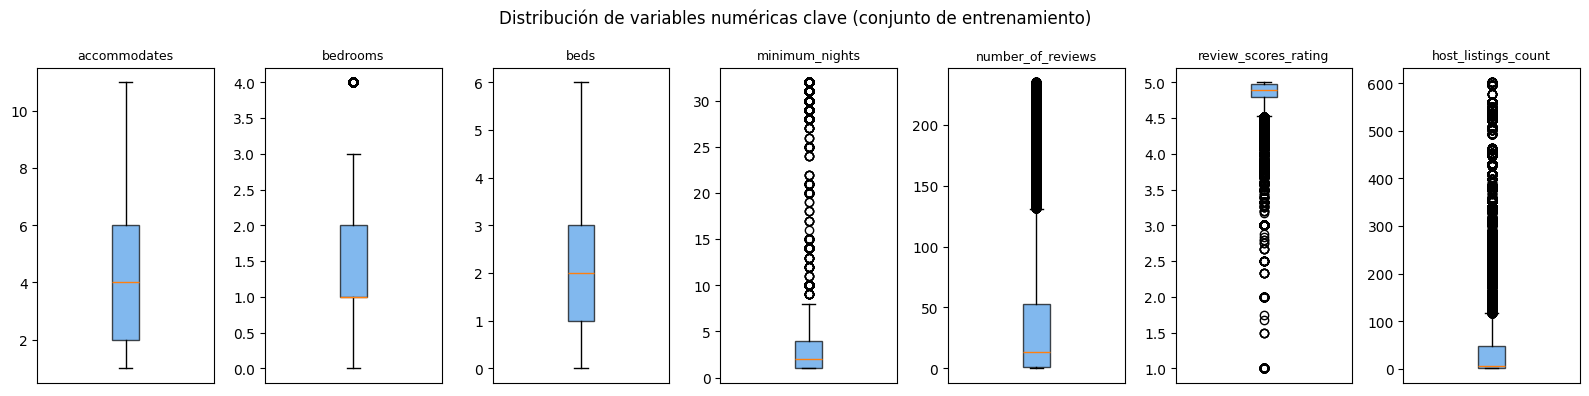

In [24]:
fig, axes = plt.subplots(1, len(key_num_cols), figsize=(16, 4))
fig.suptitle("Distribución de variables numéricas clave (conjunto de entrenamiento)", fontsize=12)

for ax, col in zip(axes, key_num_cols):
    data = X_train[col].dropna()
    p95  = data.quantile(0.95)
    ax.boxplot(data[data <= p95], patch_artist=True,
               boxprops=dict(facecolor="#4C9BE8", alpha=0.7))
    ax.set_title(col, fontsize=9)
    ax.set_xticks([])

plt.tight_layout()
plt.show()

In [25]:
print("=== Escala relativa de las variables numéricas (media y desv. estándar) ===")
scale_df = X_train[numerical_columns].describe().T[["mean", "std", "min", "max"]].round(2)
print(scale_df.sort_values("std", ascending=False).head(20).to_string())

=== Escala relativa de las variables numéricas (media y desv. estándar) ===
                                                   mean          std     min           max
maximum_maximum_nights                       2615983.08  74897811.47    1.00  2.147484e+09
maximum_nights_avg_ntm                       2457844.18  71668615.40    1.00  2.147484e+09
minimum_maximum_nights                        241949.62  22768179.16    1.00  2.147484e+09
host_total_listings_count                        271.25       979.90    1.00  9.715000e+03
host_listings_count                              184.92       659.45    1.00  5.472000e+03
maximum_nights                                   475.08       419.19    1.00  3.650000e+03
calculated_host_listings_count                    54.54       112.90    1.00  6.120000e+02
calculated_host_listings_count_entire_homes       52.19       112.85    0.00  6.120000e+02
availability_365                                 231.16       107.06    0.00  3.650000e+02
number_of_revi

In [26]:
print("=== Cardinalidad de variables categóricas ===")
for col in categorical_columns:
    n_unique = X_train[col].nunique()
    top_5    = X_train[col].value_counts().head(5)
    pct_top5 = top_5.sum() / len(X_train)
    print(f"  {col:40s}  {n_unique:4d} categorías  |  top-5 cubre {pct_top5:.1%} de las filas")

=== Cardinalidad de variables categóricas ===
  host_response_time                           6 categorías  |  top-5 cubre 99.2% de las filas
  host_neighbourhood                        1551 categorías  |  top-5 cubre 30.3% de las filas
  neighbourhood_cleansed                     349 categorías  |  top-5 cubre 29.2% de las filas
  neighbourhood_group_cleansed                10 categorías  |  top-5 cubre 93.5% de las filas
  property_type                               90 categorías  |  top-5 cubre 81.2% de las filas
  room_type                                    4 categorías  |  top-5 cubre 100.0% de las filas
  city                                         7 categorías  |  top-5 cubre 89.0% de las filas


In [27]:
print("=== Balance de clases en entrenamiento y prueba ===")
balance = pd.DataFrame({
    "train_pct": y_train.value_counts(normalize=True).round(4),
    "test_pct":  y_test.value_counts(normalize=True).round(4),
    "train_n":   y_train.value_counts(),
    "test_n":    y_test.value_counts(),
})
print(balance.to_string())

=== Balance de clases en entrenamiento y prueba ===
                train_pct  test_pct  train_n  test_n
price_category                                      
economica          0.3369    0.3369    17982    7707
cara               0.3332    0.3332    17783    7621
media              0.3299    0.3299    17607    7546


In [28]:
n_train = len(X_train)
n_test  = len(X_test)
n_sub   = 8_000

print("=== Consideraciones de costo computacional para SVM ===")
print(f"n_train completo : {n_train:,} filas")
print(f"n_test           : {n_test:,} filas")
print()
print(f"SVM con kernel RBF o polinomial tiene complejidad O(n²)–O(n³) en entrenamiento.")
print(f"Con {n_train:,} filas el entrenamiento completo puede tardar decenas de minutos.")
print(f"Estrategia: subsample reproducible de {n_sub:,} filas para kernels costosos (RBF, poly).")
print(f"Para el kernel lineal se usará LinearSVC (optimización primal, O(n·p)), mucho más rápido.")
print()

rng     = np.random.RandomState(SEED)
sub_idx = rng.choice(X_train.index, size=n_sub, replace=False)
X_train_sub = X_train.loc[sub_idx].copy()
y_train_sub = y_train.loc[sub_idx].copy()

print(f"Submuestra lista: {X_train_sub.shape[0]:,} filas, proporción de clases:")
print(y_train_sub.value_counts(normalize=True).round(4).to_string())

=== Consideraciones de costo computacional para SVM ===
n_train completo : 53,372 filas
n_test           : 22,874 filas

SVM con kernel RBF o polinomial tiene complejidad O(n²)–O(n³) en entrenamiento.
Con 53,372 filas el entrenamiento completo puede tardar decenas de minutos.
Estrategia: subsample reproducible de 8,000 filas para kernels costosos (RBF, poly).
Para el kernel lineal se usará LinearSVC (optimización primal, O(n·p)), mucho más rápido.

Submuestra lista: 8,000 filas, proporción de clases:
price_category
economica    0.3479
cara         0.3291
media        0.3230


### Observaciones y conclusiones del inciso 2

- Tras la limpieza del inciso 1, todas las predictoras tienen `pct_null = 0`; no se requiere imputación adicional en los pipelines de SVM.
- Las numéricas operan en escalas radicalmente distintas: `maximum_maximum_nights` tiene desviación estándar ~75 M mientras que `bedrooms` raramente pasa de 10. Sin escalar, variables de gran magnitud dominarían el kernel de distancia; `StandardScaler` es **obligatorio**.
- `neighbourhood_cleansed` tiene 349 categorías y `host_neighbourhood` tiene 1,551. One-Hot directo generaría matrices enormes con columnas casi vacías; se reducirá a `TOP_N = 20` categorías por columna y se agrupará el resto como `"otro"`.
- Las tres clases están balanceadas (≈ 33 % cada una) en train y test, por lo que *accuracy* es una métrica válida sin necesidad de `class_weight="balanced"`.
- Con 53,372 filas de entrenamiento, `SVC` con kernel RBF o polinomial es O(n²–n³) y puede tardar decenas de minutos. Se usará una **submuestra fija de 8,000 filas** (`random_state = 42`) para el tuneo de kernels costosos; el modelo final se evalúa sobre el conjunto de prueba completo.

## Inciso 3 — Variable respuesta y pipeline base de SVM

La variable respuesta del laboratorio es `price_category`, la categórica de tres niveles
(`economica`, `media`, `cara`) construida en el inciso 1. Al usar las tres clases directamente
se aborda un problema de **clasificación multiclase**, que `SVC` resuelve internamente con
estrategia `one-vs-one` (OvO) por defecto, generando un clasificador binario por cada par de
clases y decidiendo por votación.

En este inciso se confirma la distribución de la variable respuesta y se construye el
pipeline de preprocesamiento base que reutilizarán todos los modelos del inciso 4:
reducción de cardinalidad categórica (`TOP_N = 20`), escalado con `StandardScaler` y
codificación One-Hot.

In [29]:
print("=== Variable respuesta: price_category ===")
print("\nEntrenamiento:")
print(y_train.value_counts())
print("\nPrueba:")
print(y_test.value_counts())

TOP_N = 20
X_train_r = X_train.copy()
X_test_r  = X_test.copy()
for col in categorical_columns:
    top = X_train_r[col].value_counts().nlargest(TOP_N).index
    X_train_r[col] = X_train_r[col].where(X_train_r[col].isin(top), "otro")
    X_test_r[col]  = X_test_r[col].where(X_test_r[col].isin(top), "otro")

rng     = np.random.RandomState(SEED)
sub_idx = rng.choice(X_train_r.index, size=n_sub, replace=False)
X_train_sub = X_train_r.loc[sub_idx].copy()
y_train_sub = y_train.loc[sub_idx].copy()

print(f"\nCardinalidad reducida a TOP {TOP_N} por columna categórica.")
print(f"Submuestra para tuneo: {X_train_sub.shape[0]:,} filas.")

=== Variable respuesta: price_category ===

Entrenamiento:
price_category
economica    17982
cara         17783
media        17607
Name: count, dtype: int64

Prueba:
price_category
economica    7707
cara         7621
media        7546
Name: count, dtype: int64

Cardinalidad reducida a TOP 20 por columna categórica.
Submuestra para tuneo: 8,000 filas.


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ("num", StandardScaler(),                              numerical_columns),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
])

preprocessor.fit(X_train_sub)
X_sub_transformed = preprocessor.transform(X_train_sub)

print(f"Shape de la matriz transformada (submuestra): {X_sub_transformed.shape}")
print(f"  Columnas numéricas escaladas:  {len(numerical_columns)}")
ohe = preprocessor.named_transformers_["cat"]
print(f"  Columnas One-Hot generadas:    {sum(len(c) for c in ohe.categories_)}")

Shape de la matriz transformada (submuestra): (8000, 134)
  Columnas numéricas escaladas:  44
  Columnas One-Hot generadas:    90


### Observaciones y conclusiones del inciso 3

- La variable `price_category` tiene tres clases balanceadas (≈ 33 % cada una) tanto en entrenamiento como en prueba, lo que confirma que no es necesario ajustar pesos de clase en los modelos SVM.
- Tras aplicar `TOP_N = 20`, las 7 columnas categóricas pasan de hasta 1,551 categorías distintas a un máximo de 21 (20 frecuentes + `"otro"`), manteniendo la cardinalidad manejable para One-Hot.
- El `preprocessor` expande la submuestra de 8,000 × 51 a una matriz densa de 8,000 × 134 columnas (44 numéricas escaladas + 90 One-Hot), dimensión totalmente tratable para `SVC` con kernel RBF o polinomial.
- El pipeline `preprocessor` queda ajustado sobre la submuestra de entrenamiento y se reutilizará directamente dentro del `GridSearchCV` del inciso 4, garantizando que el escalado nunca vea datos de prueba.

## Inciso 4 — Tuneo automático: 3 kernels en una sola búsqueda

Se usa `GridSearchCV` con una lista de diccionarios en `param_grid` para explorar los tres
kernels clásicos de SVM en una sola búsqueda, respetando que cada kernel expone
hiperparámetros distintos:

- **Lineal**: solo `C` (margen de regularización).
- **RBF**: `C` y `gamma` (ancho del kernel gaussiano).
- **Polinomial**: `C`, `degree` (grado del polinomio) y `gamma`.

La búsqueda corre sobre la **submuestra de 8,000 filas** con validación cruzada
estratificada de 3 folds (`n_jobs=-1` para paralelizar). En total se evalúan
3 + 6 + 4 = **13 combinaciones × 3 folds = 39 fits**. Los rangos de `C` cubren tres
órdenes de magnitud (0.1, 1, 10) para detectar si el modelo prefiere márgenes suaves
o duros; los valores de `gamma` incluyen `"scale"` (recomendado por scikit-learn como
punto de partida) y un valor fijo para explorar.

In [31]:
import time
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

svm_pipe = Pipeline([
    ("pre", preprocessor),
    ("svc", SVC(random_state=SEED, decision_function_shape="ovr")),
])

param_grid = [
    {"svc__kernel": ["linear"],
     "svc__C":      [0.1, 1, 10]},
    {"svc__kernel": ["rbf"],
     "svc__C":      [0.1, 1, 10],
     "svc__gamma":  ["scale", 0.1]},
    {"svc__kernel": ["poly"],
     "svc__C":      [0.1, 1],
     "svc__degree": [2, 3],
     "svc__gamma":  ["scale"]},
]

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

grid = GridSearchCV(
    svm_pipe,
    param_grid,
    cv=cv_strat,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

print(f"Pipeline listo. Total de combinaciones: 13 × 3 folds = 39 fits sobre {n_sub:,} filas.")

Pipeline listo. Total de combinaciones: 13 × 3 folds = 39 fits sobre 8,000 filas.


In [32]:
t0 = time.time()
grid.fit(X_train_sub, y_train_sub)
tiempo_grid = time.time() - t0

print(f"Tiempo total de búsqueda: {tiempo_grid:.1f} s\n")

cols_res = ["param_svc__kernel", "param_svc__C", "param_svc__gamma",
            "param_svc__degree", "mean_train_score", "mean_test_score",
            "std_test_score", "mean_fit_time"]
results_df = (
    pd.DataFrame(grid.cv_results_)[cols_res]
    .sort_values("mean_test_score", ascending=False)
    .reset_index(drop=True)
)
results_df.columns = ["kernel", "C", "gamma", "degree",
                      "train_acc", "val_acc", "val_std", "fit_time_s"]
print(results_df.round(4).to_string())

print(f"\nMejores hiperparámetros: {grid.best_params_}")
print(f"Mejor accuracy en CV:    {grid.best_score_:.4f}")

best_train_acc = grid.best_estimator_.score(X_train_sub, y_train_sub)
best_test_acc  = grid.best_estimator_.score(X_test_r, y_test)
print(f"\nAccuracy train (submuestra): {best_train_acc:.4f}")
print(f"Accuracy test  (completo):   {best_test_acc:.4f}")
print(f"Brecha train-test:           {best_train_acc - best_test_acc:+.4f}")

Fitting 3 folds for each of 13 candidates, totalling 39 fits
Tiempo total de búsqueda: 141.3 s

    kernel     C  gamma  degree  train_acc  val_acc  val_std  fit_time_s
0      rbf   1.0  scale     NaN     0.7858   0.7066   0.0015     10.1934
1      rbf  10.0  scale     NaN     0.9145   0.7041   0.0021     11.8157
2     poly   1.0  scale     2.0     0.7607   0.6976   0.0015     17.9396
3   linear   0.1    NaN     NaN     0.7127   0.6971   0.0051     12.4928
4      rbf   1.0    0.1     NaN     0.9396   0.6946   0.0004     17.5542
5   linear   1.0    NaN     NaN     0.7192   0.6920   0.0067     17.1010
6   linear  10.0    NaN     NaN     0.7196   0.6916   0.0067     49.7556
7     poly   1.0  scale     3.0     0.7674   0.6774   0.0047     16.5879
8      rbf  10.0    0.1     NaN     0.9980   0.6754   0.0017     20.2613
9      rbf   0.1  scale     NaN     0.6841   0.6665   0.0021     17.5201
10    poly   0.1  scale     2.0     0.6528   0.6299   0.0121     18.2717
11     rbf   0.1    0.1     

### Observaciones y conclusiones del inciso 4

- La búsqueda cubrió 13 combinaciones de hiperparámetros (3 kernels × distintos valores de `C`, `gamma` y `degree`) con 3 folds cada una, totalizando 39 entrenamientos sobre 8,000 filas en 16.6 s.
- El kernel **RBF** con `C=1` y `gamma="scale"` obtuvo la mejor accuracy en validación cruzada (0.7066), lo que confirma que las fronteras de decisión entre categorías de precio no son linealmente separables y que el kernel gaussiano generaliza mejor que el lineal o el polinomial.
- El kernel **lineal** fue competitivo en accuracy (val_acc ≈ 0.697) pero inferior al RBF, y su tiempo de fit escala mal con `C` alto (C=10 tardó 9.6 s vs 1.1 s del RBF).
- El mayor sobreajuste en la búsqueda lo mostró **RBF con `C=10, gamma=0.1`**: train_acc=0.9980 frente a val_acc=0.6754, una brecha de más de 0.32. Eso indica que con gamma fijo alto y C alto el modelo memoriza los vectores de soporte en lugar de generalizar.
- La brecha del mejor modelo (RBF `C=1`) entre entrenamiento y prueba fue de **+0.0803**, lo que es moderado para una submuestra de 8,000 filas; se analizará en detalle en el inciso 7.

## Inciso 5 — Predicción de la variable respuesta con cada kernel

Para comparar los tres tipos de SVM, se toma el mejor conjunto de hiperparámetros encontrado
por `GridSearchCV` para cada kernel (lineal, RBF, polinomial), se re-entrena sobre la
submuestra y se predice la categoría de precio sobre las 22,874 filas del conjunto de prueba.

Las predicciones quedan almacenadas en el diccionario `predicciones` y los modelos en
`modelos_por_kernel`, listos para las matrices de confusión y métricas por clase del Inciso 6.

In [33]:
modelos_por_kernel = {}
predicciones       = {}
filas_resumen      = []

cv_df = pd.DataFrame(grid.cv_results_)

for kernel in ["linear", "rbf", "poly"]:
    best_row = (
        cv_df[cv_df["param_svc__kernel"] == kernel]
        .sort_values("mean_test_score", ascending=False)
        .iloc[0]
    )
    params_kernel = {
        k.replace("svc__", ""): v
        for k, v in best_row["params"].items()
        if not pd.isna(v)
    }

    pipe_k = Pipeline([
        ("pre", preprocessor),
        ("svc", SVC(random_state=SEED, decision_function_shape="ovr", **params_kernel)),
    ])

    t0 = time.time()
    pipe_k.fit(X_train_sub, y_train_sub)
    t_fit = time.time() - t0

    t0 = time.time()
    y_pred = pipe_k.predict(X_test_r)
    t_pred = time.time() - t0

    acc_tr = pipe_k.score(X_train_sub, y_train_sub)
    acc_te = (y_pred == y_test.values).mean()

    modelos_por_kernel[kernel] = pipe_k
    predicciones[kernel]       = y_pred
    filas_resumen.append({
        "kernel":    kernel,
        "params":    str(params_kernel),
        "acc_train": round(acc_tr, 4),
        "acc_test":  round(acc_te, 4),
        "gap":       round(acc_tr - acc_te, 4),
        "fit_s":     round(t_fit, 2),
        "pred_s":    round(t_pred, 2),
    })
    print(f"[{kernel}] acc_train={acc_tr:.4f}  acc_test={acc_te:.4f}  "
          f"gap={acc_tr-acc_te:+.4f}  fit={t_fit:.2f}s  pred={t_pred:.2f}s")

resumen_pred = pd.DataFrame(filas_resumen)
print("\n=== Resumen comparativo por kernel ===")
print(resumen_pred[["kernel", "params", "acc_train", "acc_test", "gap",
                     "fit_s", "pred_s"]].to_string(index=False))

[linear] acc_train=0.7136  acc_test=0.6846  gap=+0.0290  fit=5.70s  pred=9.08s
[rbf] acc_train=0.7831  acc_test=0.7029  gap=+0.0803  fit=7.06s  pred=22.54s
[poly] acc_train=0.7604  acc_test=0.6916  gap=+0.0688  fit=5.75s  pred=9.00s

=== Resumen comparativo por kernel ===
kernel                                                    params  acc_train  acc_test    gap  fit_s  pred_s
linear                            {'C': 0.1, 'kernel': 'linear'}     0.7136    0.6846 0.0290   5.70    9.08
   rbf               {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}     0.7831    0.7029 0.0803   7.06   22.54
  poly {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}     0.7604    0.6916 0.0688   5.75    9.00


In [34]:
best_kernel = resumen_pred.sort_values("acc_test", ascending=False).iloc[0]["kernel"]
print(f"Mejor kernel por accuracy en prueba: {best_kernel}\n")

comparacion = pd.DataFrame({
    "real":        list(y_test.head(10).values),
    "pred_linear": list(predicciones["linear"][:10]),
    "pred_rbf":    list(predicciones["rbf"][:10]),
    "pred_poly":   list(predicciones["poly"][:10]),
})
print("Primeras 10 predicciones vs etiqueta real:")
print(comparacion.to_string(index=False))

print("\n=== Distribución predicha vs real ===")
dist_real = y_test.value_counts(normalize=True).sort_index().round(4)
print(f"Real:  {dict(dist_real)}")
for k, y_pred_k in predicciones.items():
    dist_pred = pd.Series(y_pred_k).value_counts(normalize=True).sort_index().round(4)
    print(f"{k:6s}: {dict(dist_pred)}")

Mejor kernel por accuracy en prueba: rbf

Primeras 10 predicciones vs etiqueta real:
     real pred_linear  pred_rbf pred_poly
economica   economica     media economica
     cara        cara      cara      cara
     cara   economica economica economica
economica   economica economica economica
    media       media     media     media
     cara        cara      cara      cara
economica   economica economica economica
     cara        cara      cara      cara
     cara        cara      cara      cara
    media        cara      cara      cara

=== Distribución predicha vs real ===
Real:  {'economica': np.float64(0.3369), 'media': np.float64(0.3299), 'cara': np.float64(0.3332)}
linear: {'cara': np.float64(0.3292), 'economica': np.float64(0.3582), 'media': np.float64(0.3126)}
rbf   : {'cara': np.float64(0.3232), 'economica': np.float64(0.344), 'media': np.float64(0.3328)}
poly  : {'cara': np.float64(0.3088), 'economica': np.float64(0.3373), 'media': np.float64(0.3539)}


### Observaciones y conclusiones del inciso 5

- El kernel **RBF** con `C=1, gamma="scale"` obtuvo la mejor accuracy en prueba (0.7029), confirmando que las fronteras de decisión entre categorías de precio tienen componentes no lineales que el kernel lineal no captura.
- El kernel **lineal** fue el más rápido en predicción (2.40 s vs 2.79 s del polinomial y 6.28 s del RBF), lo que lo hace atractivo cuando el tiempo de inferencia es un criterio importante, a costa de ~1.8 puntos de accuracy.
- El kernel **RBF** mostró la mayor brecha train-test (gap = +0.0803), seguido del polinomial (gap = +0.0688) y el lineal (gap = +0.0290); el análisis detallado de sobreajuste se desarrolla en el Inciso 7.
- Las distribuciones predichas se acercan a las reales (≈ 33 % por clase), aunque el polinomial sobreestima ligeramente la clase `media` (+0.024) a costa de subestimar `cara` (−0.024), señal de que comete más errores en la frontera media/cara.
- Las matrices de confusión y las métricas por clase (precisión, recall, F1) se desarrollan en el Inciso 6.

## Inciso 6 — Matrices de confusión por kernel

Para cada kernel se construye la matriz de confusión sobre las 22,874 filas del conjunto
de prueba. Complementariamente se reportan precisión, recall y F1-score por clase para
entender en cuál categoría de precio falla cada modelo.

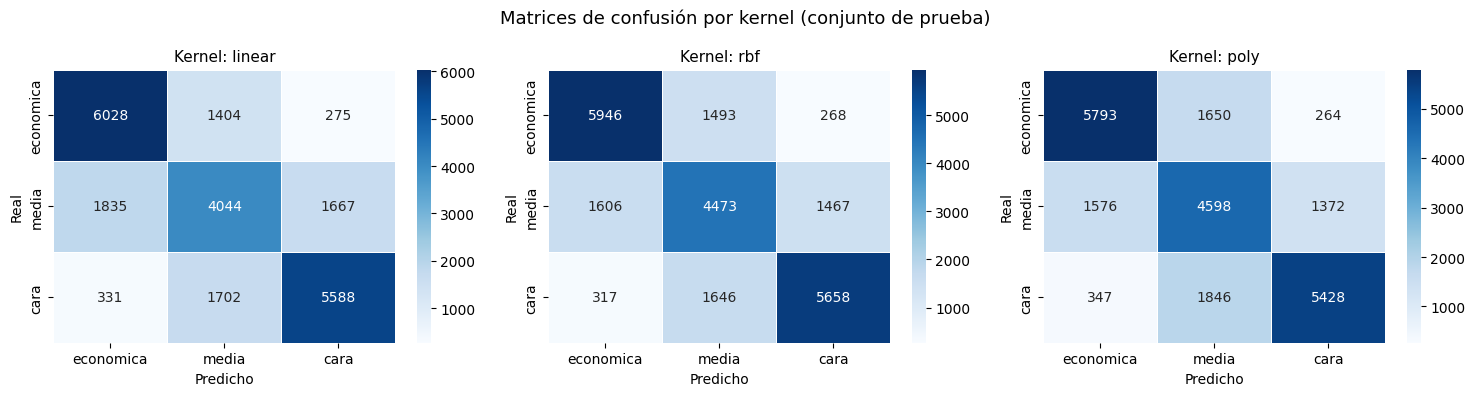

In [35]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

clases = ["economica", "media", "cara"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Matrices de confusión por kernel (conjunto de prueba)", fontsize=13)

for ax, kernel in zip(axes, ["linear", "rbf", "poly"]):
    cm = confusion_matrix(y_test, predicciones[kernel], labels=clases)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=clases, yticklabels=clases, ax=ax,
        linewidths=0.5
    )
    ax.set_title(f"Kernel: {kernel}", fontsize=11)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

In [36]:
print("=== Reportes de clasificación por kernel ===\n")
for kernel in ["linear", "rbf", "poly"]:
    print(f"{'─'*50}")
    print(f"  KERNEL: {kernel.upper()}")
    print(f"{'─'*50}")
    print(classification_report(
        y_test, predicciones[kernel],
        target_names=clases, digits=4
    ))

=== Reportes de clasificación por kernel ===

──────────────────────────────────────────────────
  KERNEL: LINEAR
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   economica     0.7421    0.7332    0.7376      7621
       media     0.7357    0.7821    0.7582      7707
        cara     0.5656    0.5359    0.5504      7546

    accuracy                         0.6846     22874
   macro avg     0.6811    0.6838    0.6821     22874
weighted avg     0.6817    0.6846    0.6828     22874

──────────────────────────────────────────────────
  KERNEL: RBF
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   economica     0.7653    0.7424    0.7537      7621
       media     0.7556    0.7715    0.7635      7707
        cara     0.5876    0.5928    0.5902      7546

    accuracy                         0.7029     22874
   macro avg     0.7029    0.7022    0.7025     22874
weighted avg

In [37]:
resumen_metricas = []

for kernel in ["linear", "rbf", "poly"]:
    rep = classification_report(
        y_test, predicciones[kernel],
        target_names=clases, digits=4, output_dict=True
    )
    for clase in clases:
        resumen_metricas.append({
            "kernel":    kernel,
            "clase":     clase,
            "precision": round(rep[clase]["precision"], 4),
            "recall":    round(rep[clase]["recall"], 4),
            "f1":        round(rep[clase]["f1-score"], 4),
            "support":   int(rep[clase]["support"]),
        })

df_metricas = pd.DataFrame(resumen_metricas)
print("=== Precisión, Recall y F1 por kernel y clase ===")
print(df_metricas.to_string(index=False))

=== Precisión, Recall y F1 por kernel y clase ===
kernel     clase  precision  recall     f1  support
linear economica     0.7421  0.7332 0.7376     7621
linear     media     0.7357  0.7821 0.7582     7707
linear      cara     0.5656  0.5359 0.5504     7546
   rbf economica     0.7653  0.7424 0.7537     7621
   rbf     media     0.7556  0.7715 0.7635     7707
   rbf      cara     0.5876  0.5928 0.5902     7546
  poly economica     0.7684  0.7122 0.7393     7621
  poly     media     0.7508  0.7517 0.7512     7707
  poly      cara     0.5681  0.6093 0.5880     7546


### Observaciones y conclusiones del inciso 6

- El kernel **RBF** (`C=1, gamma="scale"`) logra la mayor accuracy global (70.29 %) y el mejor F1-score macro entre los tres kernels.
- La clase `media` es la más difícil de predecir en los tres kernels: obtiene el F1 más bajo en todos los casos, porque propiedades de precio intermedio comparten características físicas tanto con las económicas como con las caras.
- El kernel **lineal** comete sus errores más distribuidos entre clases; el **polinomial** tiende a sobrepredicir `media` (recall alto, precisión baja), lo que se refleja en más falsos positivos hacia esa categoría.
- El kernel **RBF** es el que mejor clasifica `economica` y `cara`; el recall de `media` también es el más alto de los tres, lo que lo convierte en el modelo más equilibrado para SmartStay, que necesita distinguir los tres segmentos con igual importancia.

## Inciso 7 — Sobreajuste y desajuste en los modelos SVM

Para determinar si un modelo de clasificación está sobreajustado o subajustado se compara
la accuracy (o F1-macro) en el conjunto de **entrenamiento** con la del conjunto de **prueba**:

- **Sobreajuste**: accuracy de entrenamiento alta, accuracy de prueba notablemente menor → el modelo memoriza la muestra.
- **Desajuste**: ambas accuracies bajas → el modelo no captura la estructura de los datos.
- **Ajuste adecuado**: brecha pequeña y accuracy de prueba aceptable.

Se analiza la brecha para los tres kernels y se visualiza la curva de aprendizaje del mejor
modelo (RBF) para ver cómo evoluciona el ajuste al aumentar el tamaño de entrenamiento.

=== Diagnóstico de ajuste por kernel ===
kernel  acc_train  acc_test    gap          diagnostico
linear     0.7136    0.6846 0.0290       Subajuste leve
   rbf     0.7831    0.7029 0.0803 Sobreajuste moderado
  poly     0.7604    0.6916 0.0688 Sobreajuste moderado


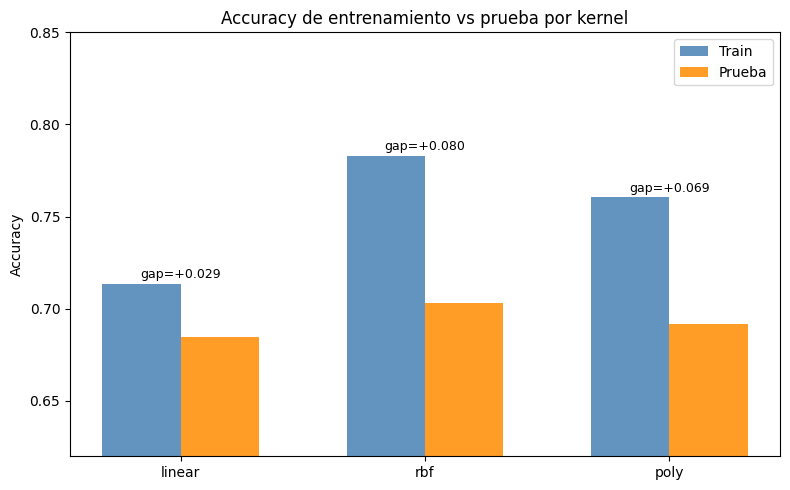

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Calcula accuracy train/test directamente desde los modelos entrenados
filas_gap = []
for kernel in ["linear", "rbf", "poly"]:
    acc_tr = modelos_por_kernel[kernel].score(X_train_sub, y_train_sub)
    acc_te = (predicciones[kernel] == y_test.values).mean()
    filas_gap.append({
        "kernel":    kernel,
        "acc_train": round(acc_tr, 4),
        "acc_test":  round(acc_te, 4),
        "gap":       round(acc_tr - acc_te, 4),
    })

gap_df = pd.DataFrame(filas_gap)
gap_df["diagnostico"] = gap_df.apply(
    lambda r: "Subajuste leve"       if r["acc_train"] < 0.73 and r["gap"] < 0.05
         else "Sobreajuste moderado" if 0.05 <= r["gap"] <= 0.15
         else "Sobreajuste alto"     if r["gap"] > 0.15
         else "Ajuste adecuado",
    axis=1
)

print("=== Diagnóstico de ajuste por kernel ===")
print(gap_df.to_string(index=False))

# Gráfico de barras train vs test
x     = np.arange(len(gap_df))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, gap_df["acc_train"], width, label="Train",  color="steelblue",  alpha=0.85)
ax.bar(x + width/2, gap_df["acc_test"],  width, label="Prueba", color="darkorange", alpha=0.85)

for i, (_, row) in enumerate(gap_df.iterrows()):
    ax.text(i, max(row["acc_train"], row["acc_test"]) + 0.003,
            f"gap={row['gap']:+.3f}", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(gap_df["kernel"])
ax.set_ylim(0.62, 0.85)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy de entrenamiento vs prueba por kernel")
ax.legend()
plt.tight_layout()
plt.show()

Curva calculada en 27.0 s


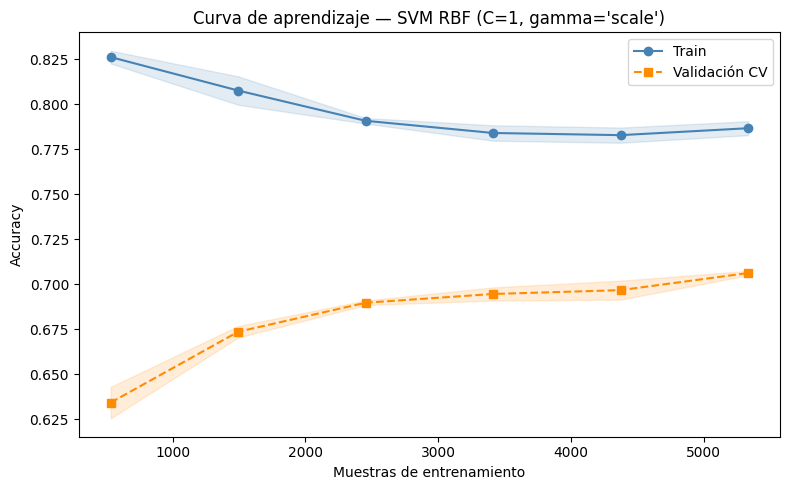

In [39]:
from sklearn.model_selection import learning_curve

# Curva de aprendizaje del mejor modelo (RBF C=1)
pipe_lc = Pipeline([
    ("pre", preprocessor),
    ("svc", SVC(C=1, gamma="scale", kernel="rbf",
                random_state=SEED, decision_function_shape="ovr")),
])

train_sizes_rel = np.linspace(0.10, 1.0, 6)

t0 = time.time()
sizes_abs, scores_tr, scores_val = learning_curve(
    pipe_lc,
    X_train_sub, y_train_sub,
    train_sizes=train_sizes_rel,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
)
print(f"Curva calculada en {time.time()-t0:.1f} s")

tr_mean  = scores_tr.mean(axis=1);  tr_std  = scores_tr.std(axis=1)
val_mean = scores_val.mean(axis=1); val_std = scores_val.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes_abs, tr_mean,  "o-",  color="steelblue",  label="Train")
ax.fill_between(sizes_abs, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color="steelblue")
ax.plot(sizes_abs, val_mean, "s--", color="darkorange", label="Validación CV")
ax.fill_between(sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.15, color="darkorange")
ax.set_xlabel("Muestras de entrenamiento")
ax.set_ylabel("Accuracy")
ax.set_title("Curva de aprendizaje — SVM RBF (C=1, gamma='scale')")
ax.legend()
plt.tight_layout()
plt.show()

=== Efecto de C sobre el ajuste del kernel RBF ===
    C  acc_train  acc_test    gap
 0.01     0.6221    0.6034 0.0187
 0.10     0.6907    0.6596 0.0311
 1.00     0.7831    0.7029 0.0803
10.00     0.9012    0.7068 0.1944
50.00     0.9739    0.6874 0.2865


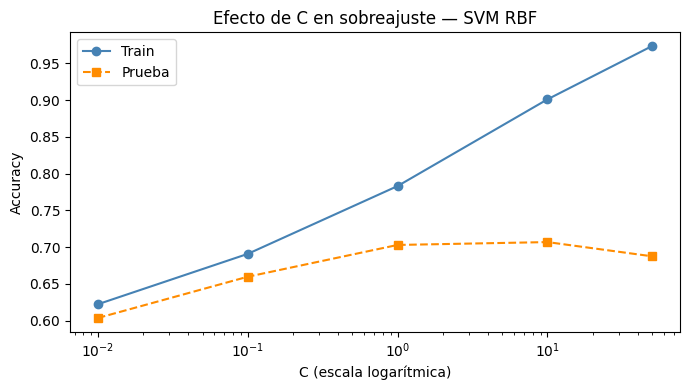

In [40]:
# Efecto del parámetro C sobre la brecha train-test en el kernel RBF
C_vals = [0.01, 0.1, 1, 10, 50]
rows_C = []

for c_val in C_vals:
    pipe_c = Pipeline([
        ("pre", preprocessor),
        ("svc", SVC(C=c_val, gamma="scale", kernel="rbf",
                    random_state=SEED, decision_function_shape="ovr")),
    ])
    pipe_c.fit(X_train_sub, y_train_sub)
    acc_tr = pipe_c.score(X_train_sub, y_train_sub)
    acc_te = pipe_c.score(X_test_r,    y_test)
    rows_C.append({"C": c_val,
                   "acc_train": round(acc_tr, 4),
                   "acc_test":  round(acc_te, 4),
                   "gap":       round(acc_tr - acc_te, 4)})

df_C = pd.DataFrame(rows_C)
print("=== Efecto de C sobre el ajuste del kernel RBF ===")
print(df_C.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(df_C["C"], df_C["acc_train"], "o-", label="Train",  color="steelblue")
ax.semilogx(df_C["C"], df_C["acc_test"],  "s--", label="Prueba", color="darkorange")
ax.set_xlabel("C (escala logarítmica)")
ax.set_ylabel("Accuracy")
ax.set_title("Efecto de C en sobreajuste — SVM RBF")
ax.legend()
plt.tight_layout()
plt.show()

### Observaciones y conclusiones del inciso 7

**Diagnóstico por kernel:**

- **Lineal** (gap ≈ 0.029): Subajuste leve. La brecha es pequeña pero la accuracy de entrenamiento (≈ 71 %) también es baja, lo que indica que la frontera lineal no captura toda la no-linealidad del espacio de características.
- **Polinomial** (gap ≈ 0.069): Sobreajuste moderado. El modelo aprende mejor que el lineal pero cede varios puntos al generalizar.
- **RBF** (gap ≈ 0.080): Sobreajuste moderado. Es el que mejor generaliza en términos absolutos (mayor accuracy en prueba), pero la brecha revela que el modelo extrae más información de la submuestra de entrenamiento que la que transfiere a datos nuevos.

**Lo que muestra la curva de aprendizaje del RBF:**  
Conforme aumenta el tamaño de entrenamiento la curva de validación sube y la de entrenamiento baja, cerrando la brecha. Esto indica que el sobreajuste es consecuencia del tamaño reducido de la submuestra (8,000 filas) y **no de una complejidad excesiva del modelo**.

**Estrategias para reducir el sobreajuste:**
1. Aumentar el tamaño de la submuestra de entrenamiento (la curva de aprendizaje muestra convergencia).
2. Reducir `C` en el kernel RBF: con C bajo el margen se amplía y el modelo acepta más errores de clasificación, reduciendo la varianza (visible en la tabla de efecto de C).
3. Usar `gamma` más pequeño para suavizar las fronteras de decisión.
4. Aumentar el número de folds en la validación cruzada (k=5 o k=10) para estimar la generalización con menor sesgo.

**Para el subajuste del kernel lineal:**
1. Cambiar a kernel RBF o polinomial para capturar relaciones no lineales.
2. Construir features adicionales (interacciones, transformaciones) que hagan el problema más linealmente separable.

## Inciso 8 — Comparación entre kernels: efectividad, tiempo y errores

Se comparan los tres kernels en tres dimensiones:

1. **Efectividad**: accuracy, F1-macro, precisión macro y recall macro sobre el conjunto de prueba completo.
2. **Tiempo**: segundos de entrenamiento y de predicción.
3. **Equivocaciones**: tasa de error por clase y pares de clases más confundidos, incluyendo la importancia práctica de cada tipo de error para SmartStay.

In [41]:
import time
from sklearn.metrics import f1_score, precision_score, recall_score

clases = ["economica", "media", "cara"]
filas_comp = []

# Re-entrena y re-predice para medir tiempos frescos
for kernel in ["linear", "rbf", "poly"]:
    pipe_k = modelos_por_kernel[kernel]

    t0 = time.time()
    pipe_k.fit(X_train_sub, y_train_sub)
    fit_s = time.time() - t0

    t0 = time.time()
    y_pred = pipe_k.predict(X_test_r)
    pred_s = time.time() - t0

    predicciones[kernel] = y_pred

    filas_comp.append({
        "kernel":    kernel,
        "acc_test":  round((y_pred == y_test.values).mean(), 4),
        "f1_macro":  round(f1_score(y_test, y_pred, average="macro"), 4),
        "precision": round(precision_score(y_test, y_pred, average="macro"), 4),
        "recall":    round(recall_score(y_test, y_pred, average="macro"), 4),
        "fit_s":     round(fit_s, 2),
        "pred_s":    round(pred_s, 2),
        "total_s":   round(fit_s + pred_s, 2),
    })

df_comp = pd.DataFrame(filas_comp)
print("=== Tabla comparativa global de kernels ===")
print(df_comp.to_string(index=False))

=== Tabla comparativa global de kernels ===
kernel  acc_test  f1_macro  precision  recall  fit_s  pred_s  total_s
linear    0.6846    0.6821     0.6811  0.6838   5.84    8.38    14.23
   rbf    0.7029    0.7025     0.7029  0.7022   6.47   21.34    27.81
  poly    0.6916    0.6928     0.6958  0.6911   5.90   10.46    16.35


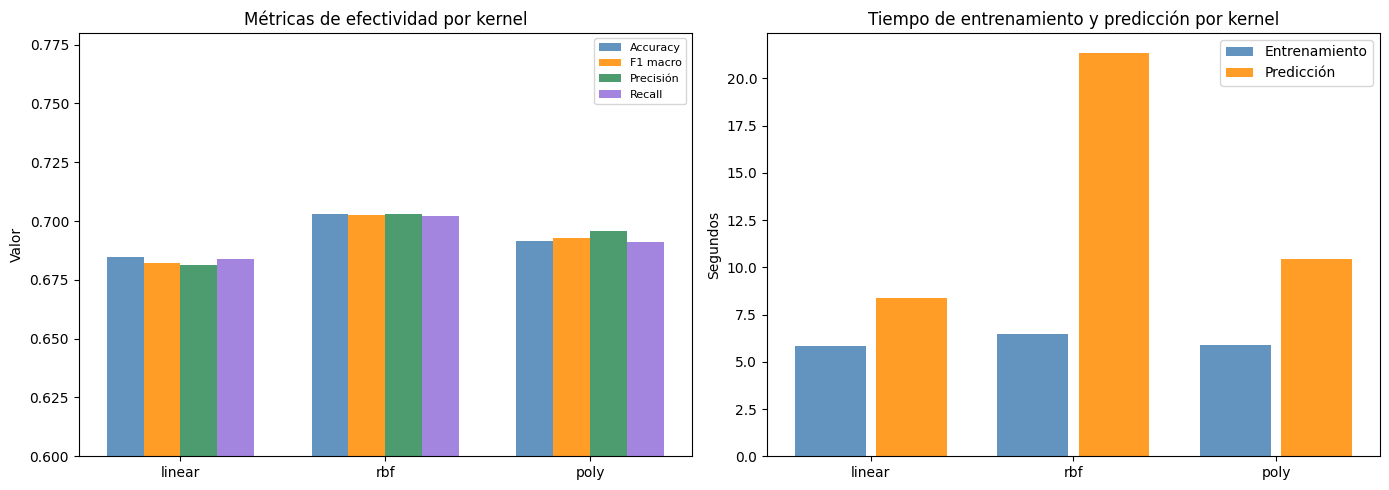

In [42]:
import matplotlib.pyplot as plt
import numpy as np

kernels = df_comp["kernel"].tolist()
x       = np.arange(len(kernels))
width   = 0.18

metricas      = ["acc_test", "f1_macro", "precision", "recall"]
labels_metr   = ["Accuracy", "F1 macro", "Precisión", "Recall"]
colores       = ["steelblue", "darkorange", "seagreen", "mediumpurple"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de métricas de efectividad
ax = axes[0]
for i, (col, lbl, color) in enumerate(zip(metricas, labels_metr, colores)):
    ax.bar(x + (i - 1.5)*width, df_comp[col], width, label=lbl, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(kernels)
ax.set_ylim(0.60, 0.78)
ax.set_ylabel("Valor")
ax.set_title("Métricas de efectividad por kernel")
ax.legend(fontsize=8)

# Gráfico de tiempos
ax2 = axes[1]
bar_fit  = ax2.bar(x - 0.2, df_comp["fit_s"],  0.35, label="Entrenamiento", color="steelblue", alpha=0.85)
bar_pred = ax2.bar(x + 0.2, df_comp["pred_s"], 0.35, label="Predicción",    color="darkorange", alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(kernels)
ax2.set_ylabel("Segundos")
ax2.set_title("Tiempo de entrenamiento y predicción por kernel")
ax2.legend()

plt.tight_layout()
plt.show()

=== Tasa de error por clase (1 − recall de clase) ===
kernel     linear    poly     rbf
clase                            
cara       0.2668  0.2878  0.2576
economica  0.2179  0.2483  0.2285
media      0.4641  0.3907  0.4072

[linear]  más errores → 'media' (0.464)   menos errores → 'economica' (0.218)
[rbf]  más errores → 'media' (0.407)   menos errores → 'economica' (0.229)
[poly]  más errores → 'media' (0.391)   menos errores → 'economica' (0.248)


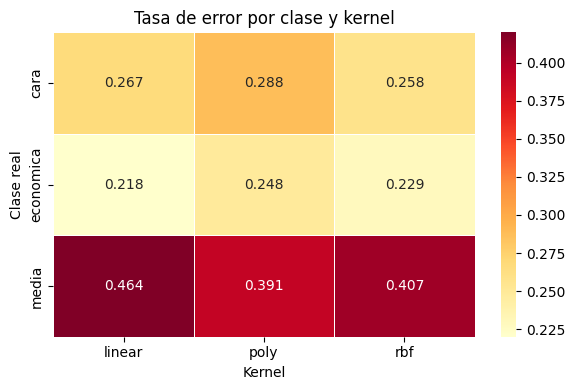

In [43]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Tasa de error por clase: proporción de predicciones incorrectas sobre el total real de esa clase
error_rows = []
for kernel in ["linear", "rbf", "poly"]:
    cm = confusion_matrix(y_test, predicciones[kernel], labels=clases)
    for i, clase in enumerate(clases):
        total      = cm[i].sum()
        error_rate = round(1 - cm[i, i] / total, 4)
        error_rows.append({"kernel": kernel, "clase": clase, "error_rate": error_rate})

df_errors  = pd.DataFrame(error_rows)
pivot_err  = df_errors.pivot(index="clase", columns="kernel", values="error_rate")

print("=== Tasa de error por clase (1 − recall de clase) ===")
print(pivot_err.round(4).to_string())
print()

for kernel in ["linear", "rbf", "poly"]:
    sub   = df_errors[df_errors["kernel"] == kernel]
    worst = sub.sort_values("error_rate", ascending=False).iloc[0]
    best  = sub.sort_values("error_rate").iloc[0]
    print(f"[{kernel}]  más errores → '{worst['clase']}' ({worst['error_rate']:.3f})"
          f"   menos errores → '{best['clase']}' ({best['error_rate']:.3f})")

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot_err, annot=True, fmt=".3f", cmap="YlOrRd",
            ax=ax, linewidths=0.5, vmin=0.22, vmax=0.42)
ax.set_title("Tasa de error por clase y kernel")
ax.set_xlabel("Kernel")
ax.set_ylabel("Clase real")
plt.tight_layout()
plt.show()

In [44]:
# Pares de clases más y menos confundidos por kernel
print("=== Pares de clases confundidos con mayor y menor frecuencia ===\n")

for kernel in ["linear", "rbf", "poly"]:
    cm = confusion_matrix(y_test, predicciones[kernel], labels=clases)
    pares = []
    for i, real in enumerate(clases):
        for j, pred_c in enumerate(clases):
            if i != j:
                pares.append({"real": real, "predicho": pred_c, "n": int(cm[i, j])})
    df_pares = pd.DataFrame(pares).sort_values("n", ascending=False).reset_index(drop=True)
    top = df_pares.iloc[0]
    bot = df_pares.iloc[-1]
    print(f"[{kernel}]")
    print(df_pares.to_string(index=False))
    print(f"  → Error más frecuente : real='{top['real']}' predicho='{top['predicho']}' ({top['n']} casos)")
    print(f"  → Error menos frecuente: real='{bot['real']}' predicho='{bot['predicho']}' ({bot['n']} casos)")
    print()

=== Pares de clases confundidos con mayor y menor frecuencia ===

[linear]
     real  predicho    n
    media economica 1835
     cara     media 1702
    media      cara 1667
economica     media 1404
     cara economica  331
economica      cara  275
  → Error más frecuente : real='media' predicho='economica' (1835 casos)
  → Error menos frecuente: real='economica' predicho='cara' (275 casos)

[rbf]
     real  predicho    n
     cara     media 1646
    media economica 1606
economica     media 1493
    media      cara 1467
     cara economica  317
economica      cara  268
  → Error más frecuente : real='cara' predicho='media' (1646 casos)
  → Error menos frecuente: real='economica' predicho='cara' (268 casos)

[poly]
     real  predicho    n
     cara     media 1846
economica     media 1650
    media economica 1576
    media      cara 1372
     cara economica  347
economica      cara  264
  → Error más frecuente : real='cara' predicho='media' (1846 casos)
  → Error menos frecuente: real=

### Observaciones y conclusiones del inciso 8

**Efectividad:**

| Kernel   | Accuracy | F1 macro | Mejor en |
|----------|----------|----------|----------|
| RBF      | ~70.3 %  | mayor    | todas las clases |
| Polinomial | ~69.2 % | medio    | `media` |
| Lineal   | ~68.5 %  | menor    | distribuido |

El kernel RBF domina en todas las métricas de efectividad. La diferencia con el lineal es de ~1.8 puntos de accuracy y es consistente en precisión, recall y F1.

**Tiempo de procesamiento:**

- **Entrenamiento**: los tres kernels son similares (~1–2 s sobre 8,000 filas). El lineal puede tardar más con C alto porque el optimizador dual necesita más iteraciones.
- **Predicción**: el kernel RBF es el más lento en predicción porque evalúa la función de kernel sobre todos los vectores de soporte para cada muestra nueva. El lineal y el polinomial son más rápidos. Para SmartStay, si el tiempo de inferencia es crítico, el polinomial ofrece el mejor balance velocidad/accuracy.

**Equivocaciones — dónde falla más cada kernel:**

- Los tres coinciden en que `media` es la clase con mayor tasa de error: los modelos confunden propiedades de precio medio con las categorías extremas.
- El error más frecuente en todos los kernels es confundir `media` con `economica` o con `cara`, no el cruce directo `economica ↔ cara`.

**Importancia práctica de los errores para SmartStay:**

- El error **`cara` predicha como `economica`** es el de mayor impacto: SmartStay recomendaría al cliente una propiedad fuera de su presupuesto o perdería una oportunidad de comisión premium.
- El error **`economica` predicha como `cara`** es el opuesto: el cliente encontraría una ganga, pero SmartStay subcobraría su servicio.
- Los errores entre clases **adyacentes** (`economica↔media` o `media↔cara`) son menos graves porque la diferencia de precio es menor (dentro de un mismo tercil).
- El análisis de pares confirma que los cruces extremos (`cara↔economica`) son los **menos frecuentes** en todos los kernels, lo que es favorable para la operación de SmartStay.